In [20]:
import numpy as np
from ase.io import write, read
import pandas as pd
import numpy.ma as ma
from math import *
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import InsetPosition
import seaborn as sns
import os
import sys

repo_root = os.path.abspath(os.path.join(os.getcwd(), "../src"))
sys.path.append(repo_root)

from dihedrals import *
from rings import *
from rdf import *

%load_ext autoreload
%autoreload 2

plt.style.use('../src/plot.mplstyle')
cm = 1/2.54

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
df=pd.read_pickle('../data/xyz/df_npt_anneal_293K_10ps_-1_generated.pckl.gzip',compression="gzip")

/var/folders/z4/v8cnfld964b8x3vqdvtc45pr0000gr/T/ipykernel_68833/2119473192.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


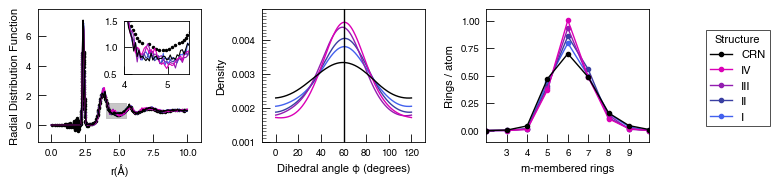

In [24]:

stru_ase=np.array(( 2512, 2545, 2561, 2568, 2490))
soap=['I', 'II', 'III', 'IV', 'CRN']
colors=['#4361EE','#3A3FA2', '#931DB0', '#DB00B6', 'k']

bins=250
rmax=10
dist_count=np.arange(rmax/(2*bins),rmax+rmax/(2*bins), rmax/bins)

fig, ax = plt.subplots(nrows=1, ncols=3,sharex=False, sharey=False,figsize=(17*cm,5*cm))
axes=ax.ravel()

##Inset plot params
axins = inset_axes(axes[0], width="100%", height="100%",loc='upper left',bbox_to_anchor=(0.5,1-0.45,.4,.4), bbox_transform=axes[0].transAxes)

# axins.set_position([0.7, 0.7, 1, 1])
inset_xlim_min=4
inset_xlim_max=5.5
inset_ylim_min=0.5
inset_ylim_max=1.5


# # Add experimental RDF
# df_rdf=pd.read_csv('../data/fig-2/g(r)_Nahkmanson.csv', names=['X', 'Y'])
# df_rdf.head(5)
# df_rdf.sort_values(by=['X'])
# df_rdf['Y']-=2
# axes[0].plot(df_rdf['X'], df_rdf['Y'], '.', color='black')
# axins.plot(df_rdf['X'], df_rdf['Y']+0.25, '.', color='black')


for item, col, label  in zip(stru_ase, colors, soap):
    atoms=df['ase_atoms'][item]

    # Plot RDF on left
    dist_count, pdf= rdf_instant(atoms, bins, rmax)
    axes[0].plot(dist_count, pdf[0], '-', color=col,label=label, alpha=1, linewidth=1)

    # Plot the inset data
    axins.plot(dist_count, pdf[0], '-', color=col, linewidth=0.8)

    # Add a rectangle indicating the region of the main plot covered by the inset
    axes[0].fill_between([inset_xlim_min, inset_xlim_max], inset_ylim_min, inset_ylim_max, color='#BDBCBD', alpha=0.3)

    # Plot dihedral in middle
    dih=comp_dihedrals(atoms)
    mid=np.asarray((dih))%120
    left=-120*np.ones(np.size(mid))+mid
    right=np.ones(np.size(mid))*120+mid
    sns.kdeplot(np.concatenate((left,mid,right)), clip=(0,120), ax=axes[1],  color=col,label=label)

    #Plot rings on right
    dict=rings_distribution(atoms, cutoff=2.85, maxlength=10)
    rings_dist_frac=np.asarray(dict['rings_dist_frac'])
    tot_frac=np.sum(rings_dist_frac[0:6])+np.sum(rings_dist_frac[7:])
    axes[2].plot(dict['rings_length'],np.asarray(dict['rings_dist'])/len(atoms),'o-', color=col,label=label, linewidth=1, markersize=3)
    

# RDF
axes[0].set_ylabel('Radial Distribution Function',  fontsize=8)
axes[0].set_xlabel('r(Å)',  fontsize=8)

axins.set_xlim(inset_xlim_min, inset_xlim_max)
axins.set_ylim(inset_ylim_min, inset_ylim_max)
axins.set_xlabel(' ')
axins.set_ylabel(' ')
# axins.set_yticks(np.arange(0.5,1.5,0.5))
# axins.set_xticks(np.arange(4,6,1))

# Dihedral
axes[1].axvline(x=60, ymin=0, ymax=1, linestyle='-' , color='k',linewidth=1)
axes[1].set_xticks(np.arange(0,140,20))
axes[1].set_yticks(np.arange(0.001,0.005,0.0001), minor=True)
axes[1].set_yticks(np.arange(0.001,0.005,0.001))
axes[1].set_xlabel('Dihedral angle φ (degrees)',  fontsize=8)
axes[1].set_ylabel('Density',  fontsize=8)

# Rings
axes[2].set_ylabel('Rings / atom', fontsize=8)
axes[2].set_xlabel('m-membered rings',  fontsize=8)
axes[2].set_xlim(2,10)
axes[2].set_xticks(np.arange(3,10))

# Beautify
handles, labels = axes[2].get_legend_handles_labels()
l=plt.legend(handles[::-1], labels[::-1], loc='upper right', bbox_to_anchor=(10.25, 1.25), title='Structure', prop={'size':8}, title_fontsize=8)
plt.setp(l.get_title(), multialignment='center')

fig.tight_layout()